# Notebook 03 — Explainability for the Lagged-Lab Recommendation
**Level:** 3 (mandatory)  
**Depends on:** Notebooks 01 and 02 must have been run so that the lagged-lab model, fallback model, feature schema, and metadata exist.  

---

## Disclaimer

- **SHAP values describe the model's learned behaviour, not causal mechanisms.**
- A variable with positive SHAP contribution is **associated with** a higher prediction under the fitted model.
- A variable with negative SHAP contribution **contributes to** a lower prediction under the fitted model.
- Operational actionability must be validated with plant experts before any process intervention is considered.

---

## Objectives
1. Load `model_lagged_lab_assumption.pkl` and its metadata from `models/selected/`.
2. Rebuild the exact feature set used in training and validate schema consistency.
3. Provide global explainability with native importance, SHAP summary, SHAP bar plot, and top SHAP feature table.
4. Provide local explanations for low-error, high-error, and representative test cases.
5. Demonstrate model sensitivity with partial dependence / PDP style analysis.
6. Compare the main explainability target against the strict no-lab-input fallback at the metadata level.
7. Check explanation consistency, flag leakage risks, and save explainability artifacts locally and optionally in MLflow.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import CFG
from src.train import load_model
from src.feature_engineering import run_feature_engineering_pipeline
from src.explain import (
    align_feature_frame,
    build_explainer,
    build_local_explanations_table,
    compute_partial_dependence_curve,
    compute_shap_values,
    get_model_feature_importance,
    infer_shap_direction,
    mean_absolute_shap,
    plot_shap_bar,
    plot_shap_summary,
    plot_shap_waterfall,
    select_explainability_cases,
 )
from src.evaluate import compute_metrics

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
FIGURES_PATH = Path(CFG['paths']['reports_figures'])
METRICS_PATH = Path(CFG['paths']['reports_metrics'])
MODELS_PATH = Path(CFG['paths']['models_selected'])
TARGET = CFG['target']

---
## 1. Load Model, Metadata, and Reconstructed Test Data

In [3]:
metadata_path = MODELS_PATH / 'selected_model_metadata.json'

feature_columns_path = MODELS_PATH / 'feature_columns.json'

primary_model_filename = 'model_lagged_lab_assumption.pkl'

legacy_model_filename = 'model.pkl'

strict_fallback_model_filename = 'model_strict_no_lab_input.pkl'

interim_path = Path(CFG['paths']['data_interim']) / 'data_cleaned.parquet'



if not metadata_path.exists():

    raise FileNotFoundError('Missing selected_model_metadata.json. Run notebook 02 first.')

if not feature_columns_path.exists():

    raise FileNotFoundError('Missing feature_columns.json. Run notebook 02 first.')

if not interim_path.exists():

    raise FileNotFoundError('Missing cleaned data in data/interim/data_cleaned.parquet. Run notebook 01 first.')



with open(metadata_path, 'r', encoding='utf-8') as f:

    selected_model_metadata = json.load(f)

with open(feature_columns_path, 'r', encoding='utf-8') as f:

    feature_columns = json.load(f)



saved_model_role = selected_model_metadata.get(

    'saved_model_role',

    'recommended_model_with_lagged_lab_assumption',

)

best_stat_meta = selected_model_metadata.get('best_statistical_model', {})

primary_meta = selected_model_metadata.get(

    'recommended_model_with_lagged_lab_assumption',

    selected_model_metadata.get('recommended_operational_model', {}),

)

fallback_meta = selected_model_metadata.get(

    'strict_no_lab_input_fallback',

    {

        'scenario': 'Not available',

        'model_name': 'Not available',

        'uses_feed_variables': None,

        'uses_target_lags': False,

        'validation_metrics': {'RMSE': np.nan},

        'test_metrics': {'R2': np.nan},

        'note': 'Strict no-lab-input fallback metadata not found. Re-run notebook 02 save cells if needed.',

    },

)

repro_meta = selected_model_metadata.get('reproducibility', {})



preferred_filenames = [primary_model_filename]

metadata_model_path = primary_meta.get('model_path', primary_meta.get('saved_model_path', '')) if primary_meta else ''

if metadata_model_path:

    metadata_candidate = Path(metadata_model_path)

    if metadata_candidate.is_absolute() and metadata_candidate.suffix.lower() == '.pkl' and metadata_candidate.exists():

        resolved_primary_model_path = metadata_candidate

    elif metadata_candidate.name:

        preferred_filenames.append(metadata_candidate.name)

else:

    resolved_primary_model_path = None



if 'resolved_primary_model_path' not in locals() or resolved_primary_model_path is None:

    preferred_filenames.append(legacy_model_filename)

    resolved_primary_model_path = None

    for candidate_filename in preferred_filenames:

        candidate_path = MODELS_PATH / candidate_filename

        if candidate_path.exists() and candidate_path.is_file():

            resolved_primary_model_path = candidate_path

            break



if resolved_primary_model_path is None:

    raise FileNotFoundError(

        'No explainability model artifact was found in models/selected. '

        f'Tried: {preferred_filenames}. Re-run notebook 02 model-saving section.'

    )



# Consistent with notebook 04: if file is under models/selected use relative filename

if resolved_primary_model_path.parent == MODELS_PATH:

    model = load_model(

        folder='selected',

        cfg=CFG,

        filename=resolved_primary_model_path.name,

    )

else:

    model = load_model(

        folder='selected',

        cfg=CFG,

        filename=resolved_primary_model_path,

    )



strict_fallback_model_path = MODELS_PATH / strict_fallback_model_filename



df_clean = pd.read_parquet(interim_path)

X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = run_feature_engineering_pipeline(

    df_clean,

    cfg=CFG,

    save=False,

    include_target_lags=bool(repro_meta.get('include_target_lags', primary_meta.get('uses_target_lags', True))),

    include_feed_features=bool(repro_meta.get('include_feed_features', primary_meta.get('uses_feed_variables', True))),

)



X_train = align_feature_frame(X_train_raw, feature_columns, dataset_name='X_train')

X_val = align_feature_frame(X_val_raw, feature_columns, dataset_name='X_val')

X_test = align_feature_frame(X_test_raw, feature_columns, dataset_name='X_test')



if list(X_test.columns) != feature_columns:

    raise ValueError(

        'X_test columns do not match feature_columns.json exactly in order and content. '

        'Re-run notebook 02 to regenerate consistent metadata/artifacts.'

    )



y_pred_test = model.predict(X_test)

test_metrics = compute_metrics(y_test, y_pred_test)



selection_rows = [

    {

        'role': 'best_statistical_model',

        'scenario': best_stat_meta.get('scenario', 'Not available'),

        'model_name': best_stat_meta.get('model_name', 'Not available'),

        'uses_feed_variables': best_stat_meta.get('uses_feed_variables'),

        'uses_target_lags': best_stat_meta.get('uses_target_lags'),

        'validation_RMSE': best_stat_meta.get('validation_metrics', {}).get('RMSE', np.nan),

        'test_R2': best_stat_meta.get('test_metrics', {}).get('R2', np.nan),

        'note': best_stat_meta.get('note', ''),

    },

    {

        'role': 'recommended_model_with_lagged_lab_assumption',

        'scenario': primary_meta.get('scenario', 'Not available'),

        'model_name': primary_meta.get('model_name', 'Not available'),

        'uses_feed_variables': primary_meta.get('uses_feed_variables'),

        'uses_target_lags': primary_meta.get('uses_target_lags'),

        'validation_RMSE': primary_meta.get('validation_metrics', {}).get('RMSE', np.nan),

        'test_R2': primary_meta.get('test_metrics', {}).get('R2', np.nan),

        'note': primary_meta.get('note', ''),

    },

]



if fallback_meta:

    selection_rows.append({

        'role': 'strict_no_lab_input_fallback',

        'scenario': fallback_meta.get('scenario', 'Not available'),

        'model_name': fallback_meta.get('model_name', 'Not available'),

        'uses_feed_variables': fallback_meta.get('uses_feed_variables'),

        'uses_target_lags': fallback_meta.get('uses_target_lags'),

        'validation_RMSE': fallback_meta.get('validation_metrics', {}).get('RMSE', np.nan),

        'test_R2': fallback_meta.get('test_metrics', {}).get('R2', np.nan),

        'note': fallback_meta.get('note', ''),

    })



selection_comparison_df = pd.DataFrame(selection_rows)



print(f'Saved model role: {saved_model_role}')

print(f'Primary explainability model class: {type(model).__name__}')

print(f'Loaded model artifact: {resolved_primary_model_path.name}')

print(f'Reconstructed X_test shape: {X_test.shape}')

print(f'Test metrics on reconstructed feature schema: {test_metrics}')

print(f'Strict fallback artifact found: {strict_fallback_model_path.exists()}')


[train] Model loaded from: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\models\selected\model_lagged_lab_assumption.pkl
[feature_engineering] Split sizes — train: 2867 (70%), val: 615 (15%), test: 615 (15%)
  Train: 2017-03-10 01:00:00 → 2017-07-20 17:00:00
  Val:   2017-07-20 18:00:00 → 2017-08-15 08:00:00
  Test:  2017-08-15 09:00:00 → 2017-09-09 23:00:00
Saved model role: recommended_model_with_lagged_lab_assumption
Primary explainability model class: RandomForestRegressor
Loaded model artifact: model_lagged_lab_assumption.pkl
Reconstructed X_test shape: (615, 261)
Test metrics on reconstructed feature schema: {'MAE': 0.55, 'RMSE': np.float64(0.7474), 'R2': 0.6096}
Strict fallback artifact found: True


---
## Model selected for explainability

The notebook interprets `models/selected/model_lagged_lab_assumption.pkl` as the **primary explainability target**.

Why this is defendable:
- it coincides with the best-performing validation model in the current run,
- it uses only past target lags rather than the contemporaneous target,
- it is acceptable if the latest laboratory result is already available at inference time,
- it preserves the main predictive signal that was lost in the strict no-lab-input fallback.

For comparison, notebook 02 also saved `model_strict_no_lab_input.pkl` as a conservative fallback. That fallback is not the main explainability target because its much weaker performance indicates that process/sensor variables alone are currently insufficient to reproduce target variability.

In [8]:
display(selection_comparison_df)

print('Explainability target: recommended_model_with_lagged_lab_assumption')
print(f"  Scenario: {primary_meta['scenario']}")
print(f"  Model:    {primary_meta['model_name']}")
print(f"  Uses target lags: {primary_meta['uses_target_lags']}")
print(f"  Uses feed variables: {primary_meta['uses_feed_variables']}")
print(f"  Test R²: {primary_meta['test_metrics']['R2']}")

print('\nComparison note versus strict fallback:')
print(f"  Strict no-lab-input fallback test R²: {fallback_meta['test_metrics']['R2']}")
print('  The explainability target remains the lagged-lab model because it preserves the dominant predictive signal under the documented lab-availability assumption.')

if primary_meta['uses_target_lags']:
    print('Interpretation rule: target lags are treated as valid past information, not automatic leakage, provided that the latest lab result is already available at inference time.')
else:
    print('This primary model does not use target lags.')

if primary_meta['uses_feed_variables']:
    print('Feed-variable assumption: the interpretation assumes feed composition variables are available at inference time.')
else:
    print('The interpreted model does not rely on feed composition availability.')

,role,scenario,model_name,uses_feed_variables,uses_target_lags,validation_RMSE,test_R2,note
0,best_statistical_model,Feed ON + TargetLags ON,Random Forest,True,True,0.6626,0.6096,Best validation RMSE overall. This role is pur...
1,recommended_model_with_lagged_lab_assumption,Feed ON + TargetLags ON,Random Forest,True,True,0.6626,0.6096,Recommended primary model under the explicit a...
2,strict_no_lab_input_fallback,Feed ON + TargetLags OFF,Random Forest,True,False,1.0006,0.0480,Conservative fallback without lagged laborator...


Explainability target: recommended_model_with_lagged_lab_assumption
  Scenario: Feed ON + TargetLags ON
  Model:    Random Forest
  Uses target lags: True
  Uses feed variables: True
  Test R²: 0.6096

Comparison note versus strict fallback:
  Strict no-lab-input fallback test R²: 0.048
  The explainability target remains the lagged-lab model because it preserves the dominant predictive signal under the documented lab-availability assumption.
Interpretation rule: target lags are treated as valid past information, not automatic leakage, provided that the latest lab result is already available at inference time.
Feed-variable assumption: the interpretation assumes feed composition variables are available at inference time.


---
## 2. Global Explainability

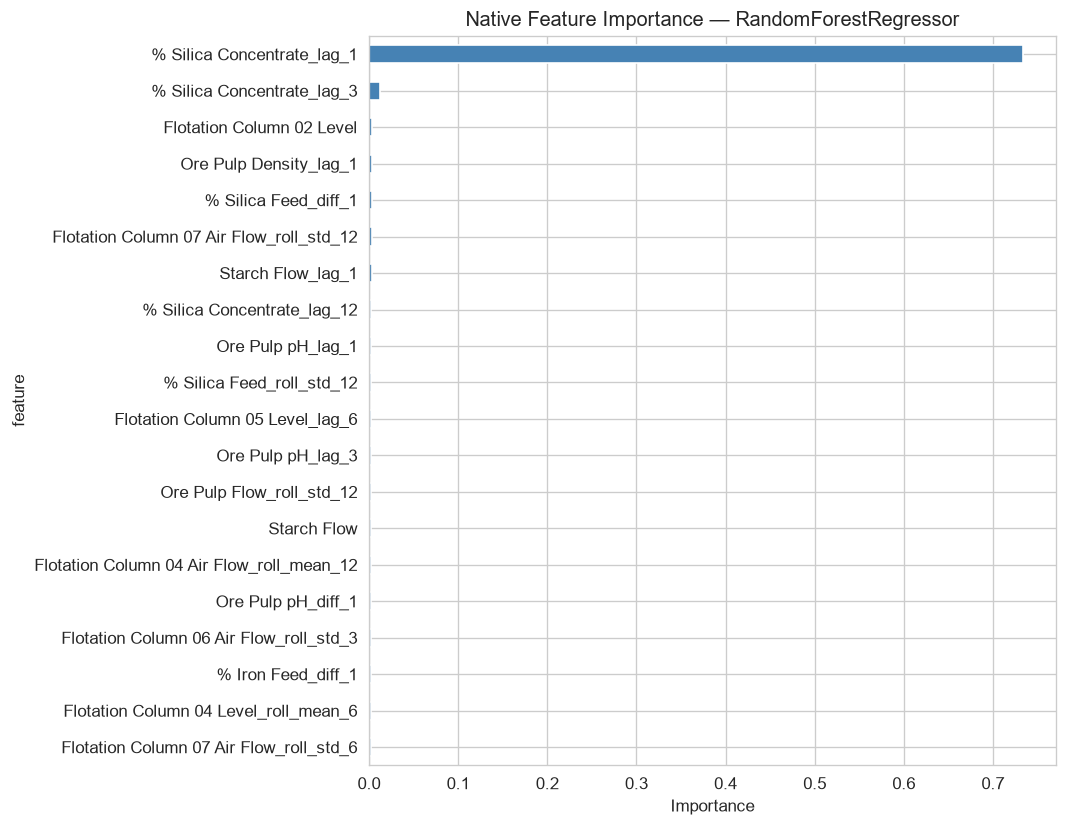

Top native-importance features:


,feature,importance
0,% Silica Concentrate_lag_1,0.734048
1,% Silica Concentrate_lag_3,0.012694
2,Flotation Column 02 Level,0.003813
3,Ore Pulp Density_lag_1,0.003297
4,% Silica Feed_diff_1,0.003046
5,Flotation Column 07 Air Flow_roll_std_12,0.002825
6,Starch Flow_lag_1,0.002817
7,% Silica Concentrate_lag_12,0.002289
8,Ore Pulp pH_lag_1,0.001997
9,% Silica Feed_roll_std_12,0.001974


In [9]:
# Native model importance when available
native_importance = get_model_feature_importance(model, feature_columns)
native_importance_path = METRICS_PATH / 'model_feature_importance.csv'

if len(native_importance) > 0:
    native_importance.to_csv(native_importance_path, index=False)
    metric_col = [c for c in native_importance.columns if c != 'feature'][0]

    fig, ax = plt.subplots(figsize=(9, 7))
    native_importance.head(20).iloc[::-1].plot(
        kind='barh',
        x='feature',
        y=metric_col,
        ax=ax,
        color='steelblue',
        legend=False,
    )
    ax.set_title(f'Native Feature Importance — {type(model).__name__}', fontsize=12)
    ax.set_xlabel(metric_col.replace('_', ' ').title())
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / 'native_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top native-importance features:')
    display(native_importance.head(10))
else:
    print('Model does not expose a native feature-importance attribute; SHAP will be the main global explanation.')

In [14]:
import importlib
import shap
import src.explain as explain_mod
explain_mod = importlib.reload(explain_mod)
from src.explain import (
    align_feature_frame,
    build_explainer,
    build_local_explanations_table,
    compute_partial_dependence_curve,
    compute_shap_values,
    get_model_feature_importance,
    infer_shap_direction,
    mean_absolute_shap,
    plot_shap_bar,
    plot_shap_summary,
    plot_shap_waterfall,
    select_explainability_cases,
 )
print(f'SHAP version: {shap.__version__}')

SHAP version: 0.52.0


In [15]:
# Build explainer and compute global SHAP values on a test-set sample
explainer = build_explainer(model, X_train)
shap_values, X_sample = compute_shap_values(explainer, X_test, cfg=CFG)
shap_importance = mean_absolute_shap(shap_values, list(X_sample.columns))
top_shap_features = shap_importance.head(10).copy()
top_shap_features_path = METRICS_PATH / 'top_shap_features.csv'
top_shap_features.to_csv(top_shap_features_path, index=False)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Top SHAP features saved to: {top_shap_features_path}')
display(top_shap_features)

[explain] Building SHAP explainer for: RandomForestRegressor
SHAP values shape: (500, 261)
Top SHAP features saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\top_shap_features.csv


,feature,mean_abs_shap
0,% Silica Concentrate_lag_1,0.677142
1,% Silica Concentrate_lag_3,0.038734
2,month,0.013290
3,Flotation Column 07 Air Flow_roll_std_12,0.013069
4,Ore Pulp Flow_lag_12,0.011096
5,Ore Pulp pH_lag_1,0.008897
6,% Silica Feed_diff_1,0.008250
7,Flotation Column 02 Level,0.006699
8,Ore Pulp pH,0.005715
9,% Silica Concentrate_lag_12,0.005501


---
## 3. SHAP Summary and Bar Plots

[explain] Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\shap_bar.png


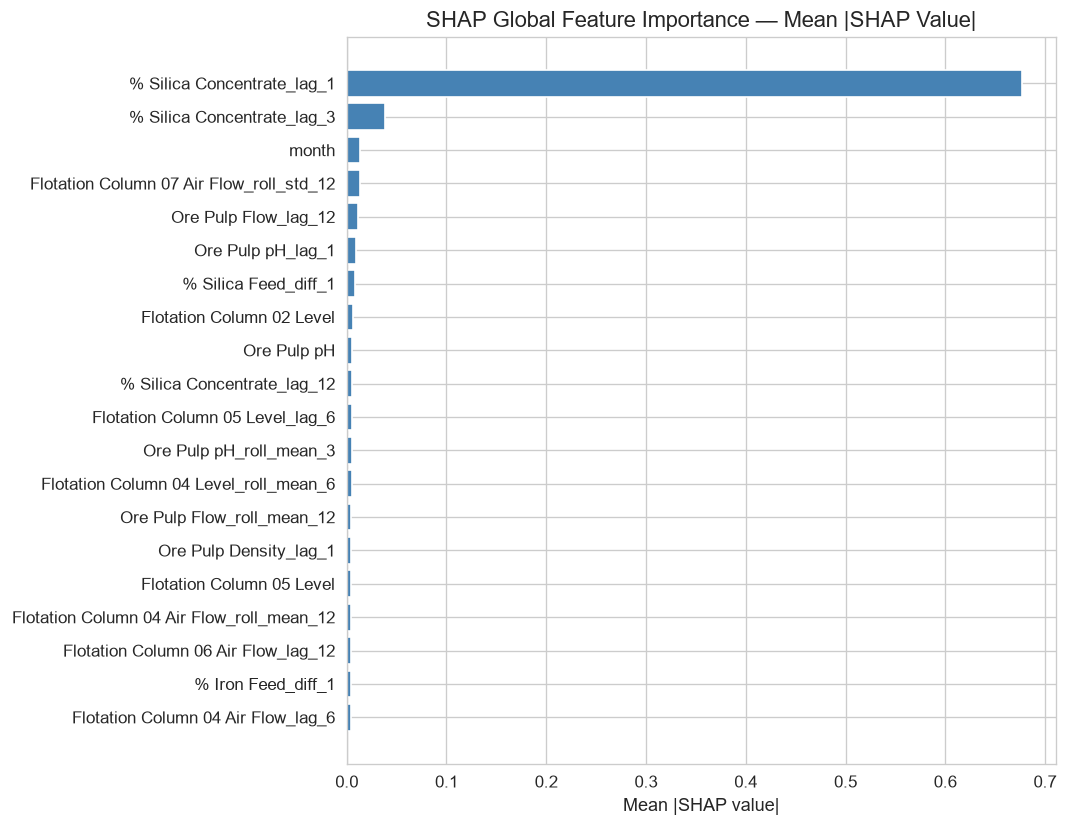

In [16]:
# SHAP bar plot (global mean absolute contribution)
fig_bar = plot_shap_bar(
    shap_values,
    X_sample,
    cfg=CFG,
    save=True,
    title='SHAP Global Feature Importance — Mean |SHAP Value|',
)
plt.show()

### Interpretation of the SHAP bar plot

The bar chart ranks the variables with the highest average absolute contribution to the prediction. These are the features the model relies on most often across the explained sample.

Operational reading: the highest-ranked variables are the strongest **drivers in the model behaviour**. They are not causal statements, but they highlight where plant experts should focus first when reviewing sensor availability, reagent strategy, and feed-quality assumptions.

[explain] Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\shap_summary.png


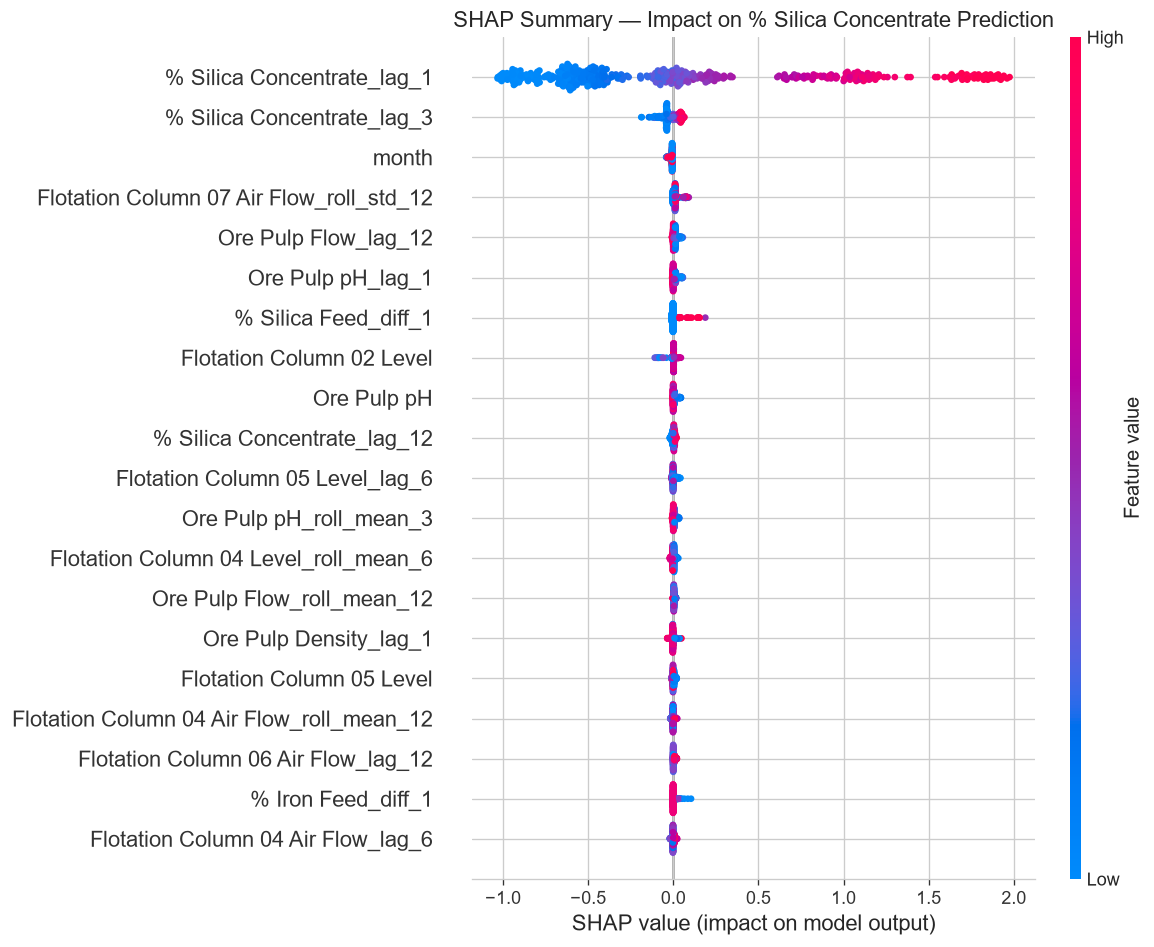

In [17]:
# SHAP summary beeswarm plot
fig_summary = plot_shap_summary(
    shap_values,
    X_sample,
    cfg=CFG,
    save=True,
    title='SHAP Summary — Impact on % Silica Concentrate Prediction',
)
plt.show()

### Interpretation of the SHAP summary plot

- Each point is one test observation and its horizontal position shows how much that feature contribution pushed the prediction up or down.
- **Positive SHAP** means the feature value is linked to a higher predicted `% Silica Concentrate` under the learned model.
- **Negative SHAP** means the feature value contributes to a lower predicted `% Silica Concentrate` under the learned model.
- The colour scale helps identify whether high or low feature values are associated with those positive or negative contributions.

Operationally, the most important rows in the summary plot are the first ones. They indicate which feed, reagent, pulp, or flotation signals the model uses most strongly when distinguishing better versus worse predicted silica conditions.

---
## 4. Operational interpretation of main drivers

In [18]:
driver_catalog = [
    {
        'label': '% Iron Feed',
        'pattern': '% Iron Feed',
        'interpretation': 'The model uses feed iron grade as a proxy for incoming ore quality and separation difficulty.',
        'caveat': 'Only valid if feed assays are available in time for inference.',
    },
    {
        'label': '% Silica Feed',
        'pattern': '% Silica Feed',
        'interpretation': 'The model associates feed silica conditions with predicted concentrate silica quality.',
        'caveat': 'Association is predictive only and depends on the online availability of feed composition.',
    },
    {
        'label': 'Starch Flow',
        'pattern': 'Starch Flow',
        'interpretation': 'The model uses starch dosage as part of the learned reagent regime linked to separation performance.',
        'caveat': 'The relationship may be non-linear and can reflect operator response as much as process state.',
    },
    {
        'label': 'Amina Flow',
        'pattern': 'Amina Flow',
        'interpretation': 'The model associates amina dosage with flotation selectivity conditions reflected in predicted silica.',
        'caveat': 'This should be interpreted with reagent strategy context and not as a direct intervention rule.',
    },
    {
        'label': 'Ore Pulp Flow',
        'pattern': 'Ore Pulp Flow',
        'interpretation': 'The model links pulp flow regime with residence time and separation behaviour proxies.',
        'caveat': 'Observed effects can mix hydrodynamics with changing ore conditions.',
    },
    {
        'label': 'Ore Pulp pH',
        'pattern': 'Ore Pulp pH',
        'interpretation': 'The model uses pH as a proxy for chemistry conditions associated with flotation response.',
        'caveat': 'Interpret as model sensitivity, not as guaranteed process response.',
    },
    {
        'label': 'Ore Pulp Density',
        'pattern': 'Ore Pulp Density',
        'interpretation': 'The model associates density with slurry condition and transport/selectivity patterns.',
        'caveat': 'Density can proxy multiple upstream phenomena, not one isolated mechanism.',
    },
    {
        'label': 'Flotation Column Air Flow',
        'pattern': 'Air Flow',
        'interpretation': 'The model uses aeration-related variables as signals linked to flotation intensity and entrainment conditions.',
        'caveat': 'Column-specific effects may differ; aggregate wording should be checked with plant experts.',
    },
    {
        'label': 'Flotation Column Level',
        'pattern': 'Level',
        'interpretation': 'The model links froth or level control signals with learned operating states associated with predicted silica.',
        'caveat': 'Level variables can also reflect operator adjustments during disturbances.',
    },
]

driver_rows = []
candidate_top_features = shap_importance.head(20)['feature'].tolist()

for item in driver_catalog:
    matches = [feat for feat in candidate_top_features if item['pattern'].lower() in feat.lower()]
    for feat in matches:
        driver_rows.append({
            'Feature': feat,
            'Direction observed in SHAP': infer_shap_direction(shap_values, X_sample, feat),
            'Operational interpretation': item['interpretation'],
            'Caveat / assumption': item['caveat'],
        })

operational_driver_table = pd.DataFrame(driver_rows).drop_duplicates(subset=['Feature'])

print('Operational interpretation of main drivers')
display(operational_driver_table)

Operational interpretation of main drivers


,Feature,Direction observed in SHAP,Operational interpretation,Caveat / assumption
0,% Iron Feed_diff_1,Higher values are linked to lower predicted si...,The model uses feed iron grade as a proxy for ...,Only valid if feed assays are available in tim...
1,% Silica Feed_diff_1,Higher values are linked to higher predicted s...,The model associates feed silica conditions wi...,Association is predictive only and depends on ...
2,Ore Pulp Flow_lag_12,Higher values are linked to lower predicted si...,The model links pulp flow regime with residenc...,Observed effects can mix hydrodynamics with ch...
3,Ore Pulp Flow_roll_mean_12,Higher values are linked to lower predicted si...,The model links pulp flow regime with residenc...,Observed effects can mix hydrodynamics with ch...
4,Ore Pulp pH_lag_1,Higher values are linked to lower predicted si...,The model uses pH as a proxy for chemistry con...,"Interpret as model sensitivity, not as guarant..."
5,Ore Pulp pH,Higher values are linked to lower predicted si...,The model uses pH as a proxy for chemistry con...,"Interpret as model sensitivity, not as guarant..."
6,Ore Pulp pH_roll_mean_3,Higher values are linked to lower predicted si...,The model uses pH as a proxy for chemistry con...,"Interpret as model sensitivity, not as guarant..."
7,Ore Pulp Density_lag_1,Higher values are linked to lower predicted si...,The model associates density with slurry condi...,"Density can proxy multiple upstream phenomena,..."
8,Flotation Column 07 Air Flow_roll_std_12,Higher values are linked to higher predicted s...,The model uses aeration-related variables as s...,Column-specific effects may differ; aggregate ...
9,Flotation Column 04 Air Flow_roll_mean_12,Higher values are linked to higher predicted s...,The model uses aeration-related variables as s...,Column-specific effects may differ; aggregate ...


In [19]:
global_driver_summary = top_shap_features.copy()
global_driver_summary['direction_observed_in_SHAP'] = global_driver_summary['feature'].apply(
    lambda feat: infer_shap_direction(shap_values, X_sample, feat)
 )

print('Top global drivers with SHAP direction')
display(global_driver_summary)

if len(operational_driver_table) == 0:
    print('None of the requested operational variable families appeared among the main SHAP drivers in this run.')
else:
    print('The operational interpretation table above only includes variables that actually appear among the important SHAP features.')

Top global drivers with SHAP direction


,feature,mean_abs_shap,direction_observed_in_SHAP
0,% Silica Concentrate_lag_1,0.677142,Higher values are linked to higher predicted s...
1,% Silica Concentrate_lag_3,0.038734,Higher values are linked to higher predicted s...
2,month,0.013290,Higher values are linked to lower predicted si...
3,Flotation Column 07 Air Flow_roll_std_12,0.013069,Higher values are linked to higher predicted s...
4,Ore Pulp Flow_lag_12,0.011096,Higher values are linked to lower predicted si...
5,Ore Pulp pH_lag_1,0.008897,Higher values are linked to lower predicted si...
6,% Silica Feed_diff_1,0.008250,Higher values are linked to higher predicted s...
7,Flotation Column 02 Level,0.006699,Higher values are linked to higher predicted s...
8,Ore Pulp pH,0.005715,Higher values are linked to lower predicted si...
9,% Silica Concentrate_lag_12,0.005501,Higher values are linked to higher predicted s...


The operational interpretation table above only includes variables that actually appear among the important SHAP features.


---
## 5. Local explainability

In [20]:
case_indices = select_explainability_cases(y_test, y_pred_test)
case_order = [case_indices['low_error'], case_indices['high_error'], case_indices['representative']]
X_cases = X_test.loc[case_order].copy()
y_cases = y_test.loc[case_order].copy()
y_pred_cases = model.predict(X_cases)
case_shap_obj = explainer(X_cases)
case_shap_values = case_shap_obj.values

local_explanations = build_local_explanations_table(
    case_shap_values,
    X_cases,
    y_cases,
    y_pred_cases,
    case_indices,
    top_n=5,
 )

def case_interpretation(row):
    return (
        f"For the {row['case_label']} case, the model links the positive SHAP drivers with higher predicted silica and the negative SHAP drivers with lower predicted silica under the learned operating pattern."
    )

local_explanations['operational_interpretation'] = local_explanations.apply(case_interpretation, axis=1)
local_explanations_path = METRICS_PATH / 'local_explanations.csv'
local_explanations.to_csv(local_explanations_path, index=False)

print(f'Local explanations saved to: {local_explanations_path}')
display(local_explanations)

Local explanations saved to: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\metrics\local_explanations.csv


,case_label,index,y_true,y_pred,error,abs_error,top_positive_drivers,top_negative_drivers,operational_interpretation
0,low_error,2017-08-22 17:00:00,1.51,1.511981,-0.001981,0.001981,% Silica Concentrate_lag_3 (0.0098); Flotation...,% Silica Concentrate_lag_1 (-0.7587); % Silica...,"For the low_error case, the model links the po..."
1,high_error,2017-08-18 06:00:00,5.27,1.344040,3.925960,3.925960,Flotation Column 04 Level_roll_std_12 (0.0129)...,% Silica Concentrate_lag_1 (-0.9077); % Silica...,"For the high_error case, the model links the p..."
2,representative,2017-08-19 12:00:00,2.02,2.381788,-0.361788,0.361788,Ore Pulp Flow_lag_12 (0.0554); Flotation Colum...,month (-0.0303); Flotation Column 06 Air Flow_...,"For the representative case, the model links t..."


y_true                                                                     1.51
y_pred                                                                 1.511981
error                                                                 -0.001981
top_positive_drivers          % Silica Concentrate_lag_3 (0.0098); Flotation...
top_negative_drivers          % Silica Concentrate_lag_1 (-0.7587); % Silica...
operational_interpretation    For the low_error case, the model links the po...
Name: 0, dtype: object
[explain] Saved: \\fileserv\alumnos\A.alvarezdelatorres\Desktop\MINSUR\minsur-quality-prediction\reports\figures\shap_waterfall_0_low_error_case.png


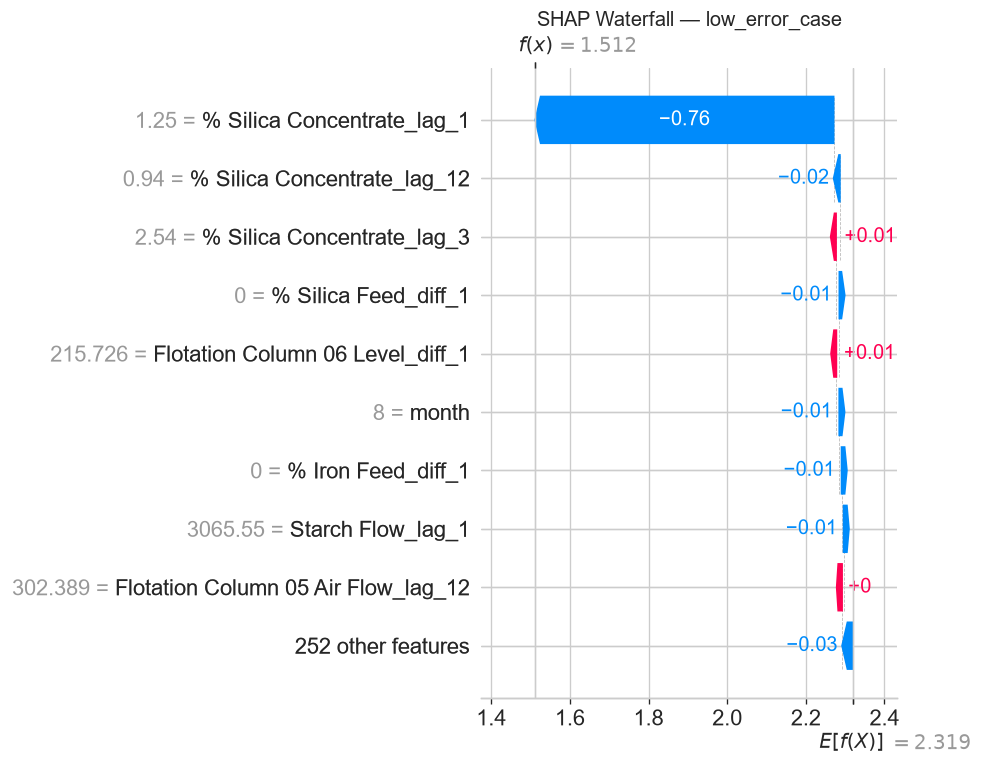

In [21]:
# Local case 1 — low error prediction
low_error_index = case_indices['low_error']
low_error_row = local_explanations[local_explanations['case_label'] == 'low_error'].iloc[0]
print(low_error_row[['y_true', 'y_pred', 'error', 'top_positive_drivers', 'top_negative_drivers', 'operational_interpretation']])

plot_shap_waterfall(
    explainer,
    X_test.loc[[low_error_index]],
    obs_idx=0,
    cfg=CFG,
    save=True,
    title_suffix='low_error_case',
)

In [ ]:
# Local case 2 — high error prediction
high_error_index = case_indices['high_error']
high_error_row = local_explanations[local_explanations['case_label'] == 'high_error'].iloc[0]
print(high_error_row[['y_true', 'y_pred', 'error', 'top_positive_drivers', 'top_negative_drivers', 'operational_interpretation']])

plot_shap_waterfall(
    explainer,
    X_test.loc[[high_error_index]],
    obs_idx=0,
    cfg=CFG,
    save=True,
    title_suffix='high_error_case',
)

In [ ]:
# Local case 3 — representative / median-target prediction
representative_index = case_indices['representative']
representative_row = local_explanations[local_explanations['case_label'] == 'representative'].iloc[0]
print(representative_row[['y_true', 'y_pred', 'error', 'top_positive_drivers', 'top_negative_drivers', 'operational_interpretation']])

plot_shap_waterfall(
    explainer,
    X_test.loc[[representative_index]],
    obs_idx=0,
    cfg=CFG,
    save=True,
    title_suffix='representative_case',
)

---
## 6. Partial dependence / sensitivity analysis

For the top SHAP features, the next plots show **model sensitivity**, not causal effect. They answer: *how does the fitted model prediction change when one variable moves across its observed range while the rest of the feature distribution is averaged out?*

In [ ]:
top_pdp_features = shap_importance['feature'].head(min(5, len(shap_importance))).tolist()
pdp_artifact_paths = []

for feature_name in top_pdp_features:
    pdp_curve = compute_partial_dependence_curve(model, X_test, feature_name)
    safe_name = re.sub(r'[^A-Za-z0-9]+', '_', feature_name).strip('_').lower()
    pdp_path = FIGURES_PATH / f'pdp_{safe_name}.png'

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(pdp_curve['feature_value'], pdp_curve['predicted_response'], color='steelblue', lw=2)
    ax.set_title(f'Partial Dependence — {feature_name}', fontsize=11)
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Average predicted % Silica Concentrate')
    plt.tight_layout()
    plt.savefig(pdp_path, dpi=150, bbox_inches='tight')
    plt.show()

    pdp_artifact_paths.append(str(pdp_path))

print('PDP / sensitivity artifacts saved:')
for path in pdp_artifact_paths:
    print(f'  {path}')

---
## Explanation consistency checks

This section verifies whether the global and local explanations are coherent with the fitted model and whether any suspicious feature family suggests operational leakage risk.

In [ ]:
shap_top_features = top_shap_features['feature'].tolist()

if len(native_importance) > 0:
    native_top_features = native_importance.head(10)['feature'].tolist()
    importance_overlap = sorted(set(shap_top_features).intersection(native_top_features))
    print(f'Overlap between native importance and SHAP top features: {importance_overlap}')
else:
    native_top_features = []
    importance_overlap = []
    print('No native feature importance available for overlap comparison.')

case_base_values = np.ravel(case_shap_obj.base_values)
case_reconstructed_predictions = case_base_values + case_shap_values.sum(axis=1)
consistency_rows = []
for idx_value, approx_pred, direct_pred in zip(X_cases.index, case_reconstructed_predictions, y_pred_cases):
    consistency_rows.append({
        'index': idx_value,
        'shap_reconstructed_prediction': float(approx_pred),
        'model_prediction': float(direct_pred),
        'absolute_difference': float(abs(approx_pred - direct_pred)),
    })

local_consistency_df = pd.DataFrame(consistency_rows)
lagged_lab_features = [
    feat for feat in feature_columns
    if TARGET.lower() in feat.lower() and 'lag' in feat.lower()
 ]

print('Global consistency check:')
print('- SHAP vs native feature importance overlap is expected to be partial but reasonable for stable models.')
print('- Local additive check should show very small differences between SHAP reconstruction and direct model prediction.')
display(local_consistency_df)

if lagged_lab_features:
    print('Past target-lag features detected in the explainability schema:')
    for feat in lagged_lab_features:
        print(f'  {feat}')
    print('These are acceptable only under the documented assumption that the latest lab result is already available before inference.')
else:
    print('No target-lag features were detected in the saved feature schema.')

if len(operational_driver_table) > 0:
    print('Operational sense check: the main SHAP drivers include process variables that can be discussed with plant experts.')
else:
    print('Operational sense check: the main SHAP drivers should be reviewed manually because the predefined variable families did not dominate this run.')

explainability_artifact_paths = [
    str(FIGURES_PATH / 'shap_summary.png'),
    str(FIGURES_PATH / 'shap_bar.png'),
    str(METRICS_PATH / 'top_shap_features.csv'),
    str(METRICS_PATH / 'local_explanations.csv'),
]
if (FIGURES_PATH / 'native_feature_importance.png').exists():
    explainability_artifact_paths.append(str(FIGURES_PATH / 'native_feature_importance.png'))
explainability_artifact_paths.extend(pdp_artifact_paths)

raw_experiment_name = CFG.get('mlflow', {}).get('experiment_name', '').strip()
legacy_names = {'', 'minsur', 'minsur-silica-prediction'}
if raw_experiment_name in legacy_names:
    explainability_experiment_name = 'MINSUR Silica Prediction - Temporal Modeling'
else:
    explainability_experiment_name = raw_experiment_name

explainability_tracking_status = {
    'status': 'local_fallback',
    'message': 'MLflow logging not completed; artifacts remain available locally.',
}

try:
    import os
    import mlflow

    tracking_path = Path(CFG['paths']['mlruns'])
    tracking_path.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault('MLFLOW_ALLOW_FILE_STORE', 'true')
    mlflow.set_tracking_uri(str(tracking_path))
    mlflow.set_experiment(explainability_experiment_name)

    with mlflow.start_run(run_name='explainability_recommended_model') as run:
        mlflow.set_tag('notebook', '03_explainability')
        mlflow.set_tag('model_role', saved_model_role)
        mlflow.log_param('scenario', primary_meta['scenario'])
        mlflow.log_param('model_name', primary_meta['model_name'])
        mlflow.log_param('uses_feed_variables', primary_meta['uses_feed_variables'])
        mlflow.log_param('uses_target_lags', primary_meta['uses_target_lags'])
        mlflow.log_metric('test_MAE', float(test_metrics['MAE']))
        mlflow.log_metric('test_RMSE', float(test_metrics['RMSE']))
        mlflow.log_metric('test_R2', float(test_metrics['R2']))
        mlflow.log_metric('strict_fallback_test_R2', float(fallback_meta['test_metrics']['R2']))

        for artifact_path in explainability_artifact_paths:
            artifact_file = Path(artifact_path)
            if artifact_file.exists():
                mlflow.log_artifact(str(artifact_file))

        explainability_tracking_status = {
            'status': 'mlflow_logged',
            'run_id': run.info.run_id,
            'experiment_name': explainability_experiment_name,
            'message': 'Explainability artifacts logged to MLflow and preserved locally.',
        }
except Exception as exc:
    explainability_tracking_status = {
        'status': 'local_fallback',
        'message': f'MLflow logging failed; explainability artifacts remain saved locally. Reason: {exc}',
    }

print(explainability_tracking_status['message'])
display(pd.DataFrame([explainability_tracking_status]))

---
## Executive conclusions — Explainability

- **Main explainability target:** this notebook explains `model_lagged_lab_assumption.pkl`, which is the primary technical recommendation from notebook 02 under the documented assumption that the latest laboratory result is available before inference.
- **Comparison with fallback:** notebook 02 also saved `model_strict_no_lab_input.pkl` as a conservative fallback. Its much weaker test performance is documented for context, but it is not the main model interpreted here.
- **Main drivers under the learned model:** the top SHAP features identify which lagged quality, feed, reagent, pulp, and flotation signals most strongly contribute to predicted `% Silica Concentrate`.
- **Global explanations delivered:** native importance (when available), SHAP summary, SHAP bar plot, and `top_shap_features.csv` provide a reproducible global view of model behaviour.
- **Local explanations delivered:** one low-error case, one high-error case, and one representative test case were explained with top positive and negative SHAP drivers and saved to `local_explanations.csv`.
- **Sensitivity delivered:** PDP / sensitivity plots show how the fitted model prediction changes across important variables, with explicit non-causal interpretation.
- **Main limitations:** explanations remain predictive rather than causal; the acceptability of lagged lab features depends on real laboratory turnaround; feed-variable interpretations depend on online availability assumptions; and all important variables should be reviewed with plant experts before any operating recommendation is inferred.
- **Variables to validate with plant experts:** the highest-ranked SHAP drivers, especially lagged quality, feed composition, reagent flows, pulp chemistry, and flotation column control variables that dominate the model output.
- **Level 4 bridge:** these explainability outputs identify which variables are most suitable for controlled what-if simulations in notebook 04, particularly those that are both operationally meaningful and traceable in real time.

## Level 3 checklist

| Requirement | Status |
|---|---|
| Identify key drivers influencing `% Silica Concentrate` | ✅ |
| Provide global explanations | ✅ |
| Provide local explanations | ✅ |
| Demonstrate how changes in important variables affect predictions | ✅ |
| Ensure explanations are coherent with model behavior | ✅ |
| Avoid causal claims | ✅ |